##Laboratorio 2 - Fisica computacional 2

In [2]:
!pip install fitter --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 4.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.5.3 which is incompatible.


In [1]:
#Librerias
!pip install --upgrade numpy scipy
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Parte 1

In [75]:
URL_EURUSD = ("https://raw.githubusercontent.com/hernansalinas/"
              "Curso_aprendizaje_estadistico/main/datasets/"
              "Pandas_data_historical_dataEURUSD.csv")

# index_col=0 descarta la columna 'Unnamed: 0' (índice guardado al exportar el csv)
eurusd = pd.read_csv(URL_EURUSD, index_col=0, parse_dates=["time"])

print("Dimensiones del dataset:", eurusd.shape)

Dimensiones del dataset: (5000, 12)


In [3]:
eurusd = eurusd.set_index("time") # Definimos como indice time
eurusd = eurusd.sort_index()   # garantizamos orden cronológico

print("Tipo de índice:", type(eurusd.index).__name__) #Verificamos el indice
print("Fecha inicial :", eurusd.index.min())
print("Fecha final   :", eurusd.index.max())
eurusd.head()

Tipo de índice: DatetimeIndex
Fecha inicial : 2022-07-25 13:00:00
Fecha final   : 2023-05-12 23:00:00


,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,
2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


In [4]:
eurusd.info() #Informacion sobre el dataset

<class 'pandas.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   open                5000 non-null   float64
 1   high                5000 non-null   float64
 2   low                 5000 non-null   float64
 3   close               5000 non-null   float64
 4   tick_volume         5000 non-null   int64  
 5   spread              5000 non-null   int64  
 6   real_volume         5000 non-null   int64  
 7   MeanCloseOpen       5000 non-null   float64
 8   Diff_Close          5000 non-null   float64
 9   Diff_Open           5000 non-null   float64
 10  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 468.8 KB


In [5]:
# Estadística descriptiva de todas las columnas numéricas
eurusd.describe()

,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.000000,5000.000000,5000.000000,5000.000000
mean,1.043891,1.044815,1.042991,1.043906,3690.249400,8.981600,0.0,1.043898,0.000012,0.000012,0.000012
std,0.041135,0.040991,0.041263,0.041135,2800.488505,5.785115,0.0,0.041129,0.001400,0.001404,0.000978
min,0.953910,0.955930,0.953570,0.953910,85.000000,0.000000,0.0,0.954735,-0.013970,-0.014010,-0.007260
25%,1.002718,1.003507,1.001715,1.002705,1738.750000,8.000000,0.0,1.002648,-0.000580,-0.000600,-0.000425
50%,1.055670,1.056795,1.054960,1.055700,2999.500000,8.000000,0.0,1.055712,-0.000005,0.000000,0.000005
75%,1.078940,1.079582,1.078222,1.078947,4861.000000,8.000000,0.0,1.078955,0.000620,0.000612,0.000430
max,1.108470,1.109530,1.108050,1.108500,23708.000000,183.000000,0.0,1.108280,0.017340,0.017420,0.010780


In [6]:
nulos_por_columna = eurusd.isnull().sum() #Pero antes en .info ya habiamos visto que no hay nulos, igual miramos
print("Valores nulos por columna:")
print(nulos_por_columna)
print()
print("nulos en el DataFrame:", eurusd.isnull().sum().sum())
print("¿Hay algún NaN?", eurusd.isna().any().any())

Valores nulos por columna:
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64

nulos en el DataFrame: 0
¿Hay algún NaN? False


In [88]:
#5)Utilizamos la notacion de Pacal Case
def a_pascal_case(nombre):
    palabras = re.split(r"[_\s]+", nombre)
    return "".join(p[:1].upper() + p[1:] for p in palabras)


In [89]:
eurusd = eurusd.rename(columns=a_pascal_case)
eurusd.index.name = "Time"

print("Columnas en PascalCase:")
print(list(eurusd.columns))
eurusd.head()

Columnas en PascalCase:
['Time', 'Open', 'High', 'Low', 'Close', 'TickVolume', 'Spread', 'RealVolume', 'MeanCloseOpen', 'DiffClose', 'DiffOpen', 'DiffMeanCloseOpen']


,Time,Open,High,Low,Close,TickVolume,Spread,RealVolume,MeanCloseOpen,DiffClose,DiffOpen,DiffMeanCloseOpen
Time,,,,,,,,,,,,
0,2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
1,2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2,2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
3,2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
4,2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


In [90]:
eurusd = eurusd.set_index('Time')
eurusd.index = pd.to_datetime(eurusd.index)
print("Tipo de índice después de la corrección:", type(eurusd.index).__name__)

Tipo de índice después de la corrección: DatetimeIndex


In [92]:
# Solo usamos el precio de cierre
precio = eurusd[["Close"]].copy()
precio.head()

,Close
Time,
2022-07-25 13:00:00,1.02345
2022-07-25 14:00:00,1.02299
2022-07-25 15:00:00,1.02457
2022-07-25 16:00:00,1.02485
2022-07-25 17:00:00,1.02181


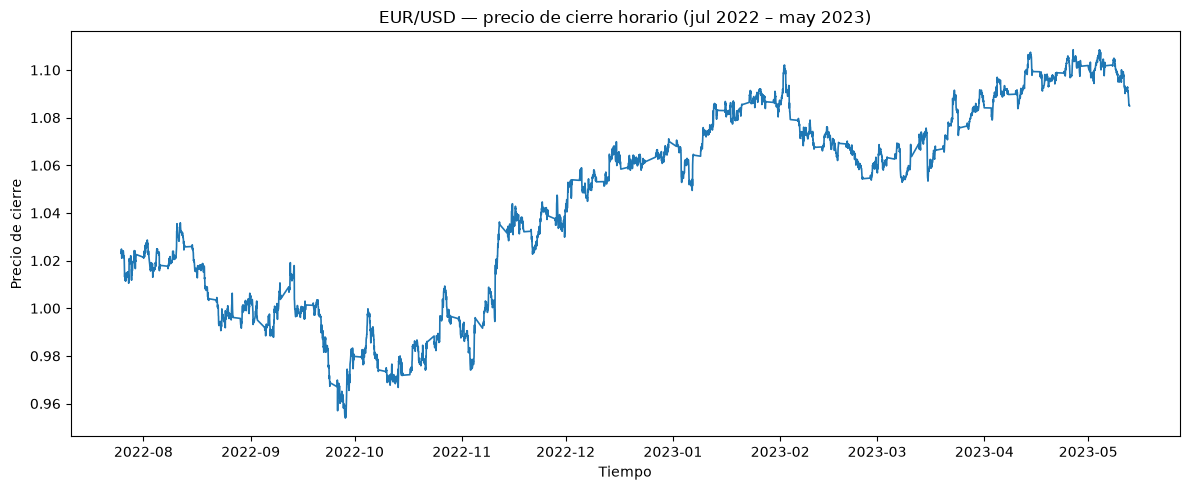

In [93]:
#Visualizamos el precio de cierre en la serie de tiempo
precio = eurusd[["Close"]].copy()

plt.figure(figsize=(12, 5))
plt.plot(precio.index, precio["Close"], linewidth=1.2)
plt.title("EUR/USD — precio de cierre horario (jul 2022 – may 2023)")
plt.xlabel("Tiempo")
plt.ylabel("Precio de cierre")
plt.tight_layout()
plt.show()

In [96]:
#Diferencia de precio
precio["DiffPrice"] = precio["Close"].diff()
precio.head() #Verificamos que tenga df tenga las dos columnas que nos piden

,Close,DiffPrice
Time,,
2022-07-25 13:00:00,1.02345,NaN
2022-07-25 14:00:00,1.02299,-0.00046
2022-07-25 15:00:00,1.02457,0.00158
2022-07-25 16:00:00,1.02485,0.00028
2022-07-25 17:00:00,1.02181,-0.00304


In [98]:
print("NaN generados por diff():", precio["DiffPrice"].isna().sum())

# Serie limpia que usaremos para el ajuste
diff_precio = precio["DiffPrice"].dropna()
print("Número de datos para el ajuste:", len(diff_precio))
diff_precio.describe()

NaN generados por diff(): 1
Número de datos para el ajuste: 4999


count    4999.000000
mean        0.000012
std         0.001401
min        -0.013970
25%        -0.000580
50%         0.000000
75%         0.000620
max         0.017340
Name: DiffPrice, dtype: float64

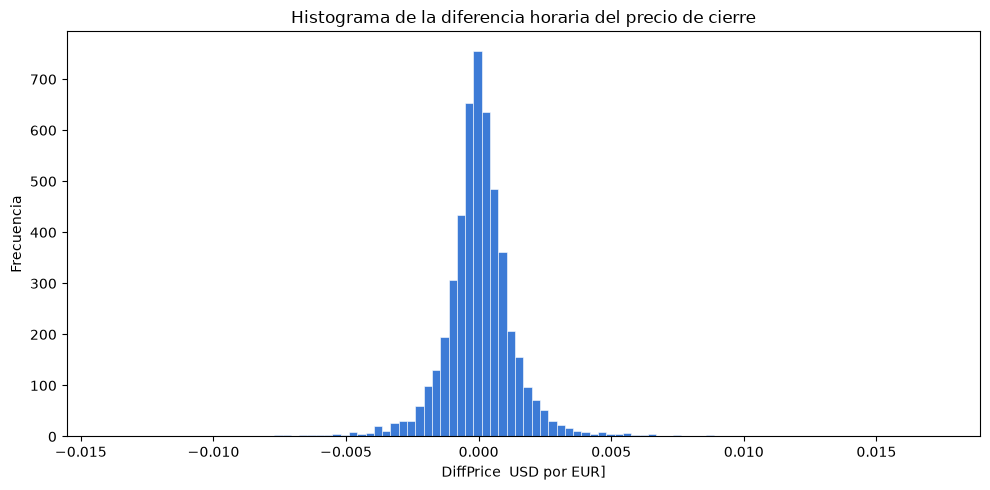

In [99]:
plt.figure(figsize=(10, 5))
plt.hist(diff_precio, bins=100, color="#3D7BD6", edgecolor="white", linewidth=0.4)
plt.title("Histograma de la diferencia horaria del precio de cierre")
plt.xlabel("DiffPrice  USD por EUR]")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [100]:
# Estadísticos de forma nos anticipan qué familia de distribuciones puede servir
print(f"Media      : {diff_precio.mean(): .6f}")
print(f"Mediana    : {diff_precio.median(): .6f}")
print(f"Desv. est. : {diff_precio.std(): .6f}")
print(f"Asimetría  : {stats.skew(diff_precio): .4f}")
print(f"Curtosis   : {stats.kurtosis(diff_precio): .4f}   (0 = normal)")

Media      :  0.000012
Mediana    :  0.000000
Desv. est. :  0.001401
Asimetría  :  0.2554
Curtosis   :  13.3128   (0 = normal)


In [101]:
from fitter import Fitter, get_common_distributions, get_distributions

datos = diff_precio.values   #Lo escribimos como arreglo de numpy

lista_distribuciones = [
    "norm",       # sugeridas en el enunciado
    "gamma",
    "lognorm",
    "beta",
    "burr",
    "laplace",    # De las sugeridas ene l ejerccioso solo se ajusta norm, entonces debido a la cortusisis se ponene estas
    "t",
    "cauchy",
    "logistic",
    "hypsecant",
]

ajuste = Fitter(datos, distributions=lista_distribuciones)
ajuste.fit()

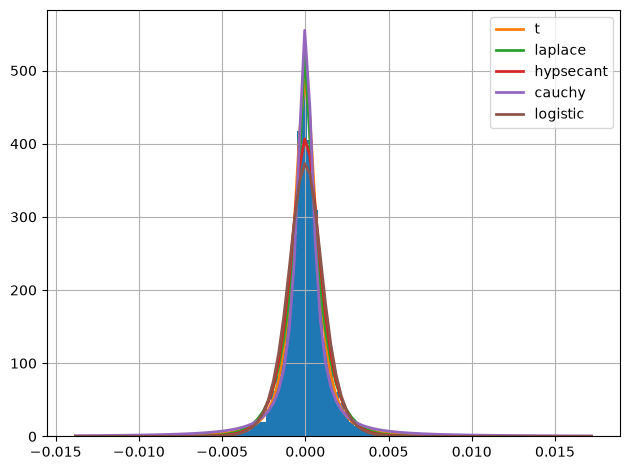

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
t,2648.868472,-53108.797686,-53089.246706,0.138297,0.012501,4.120332e-01
laplace,6365.894410,-53045.776278,-53032.742292,0.018699,0.017483,9.306124e-02
hypsecant,12523.318706,-52912.997241,-52899.963255,0.019791,0.031602,9.008532e-05
cauchy,23122.545603,-52492.692248,-52479.658261,0.524401,0.042450,2.893321e-08
logistic,27646.449815,-52700.591834,-52687.557847,0.030989,0.044193,6.378792e-09


In [103]:
# las 5 mejores según el error cuadrático de suma
resumen = ajuste.summary(Nbest=5)
plt.tight_layout()
plt.show()
resumen

In [19]:
mejor = ajuste.get_best(method="sumsquare_error")

nombre_mejor = list(mejor.keys())[0]
parametros_mejor = mejor[nombre_mejor]

print("Mejor distribución según sumsquare_error:", nombre_mejor)
print("Parámetros ajustados:")
for k, v in parametros_mejor.items():
    print(f"   {k} = {v:.8f}")

Mejor distribución según sumsquare_error: t
Parámetros ajustados:
   df = 1.98921527
   loc = -0.00000342
   scale = 0.00072681


In [104]:
print("Parámetros de la distribución beta:", ajuste.fitted_param["beta"])
print("Parámetros de la distribución norm:", ajuste.fitted_param["norm"])

Parámetros de la distribución beta: (np.float64(14613.868594375072), np.float64(27361.660606098114), np.float64(-0.2096488866774875), np.float64(0.6022115067129248))
Parámetros de la distribución norm: (np.float64(1.2300460092018413e-05), np.float64(0.0014004793955818403))


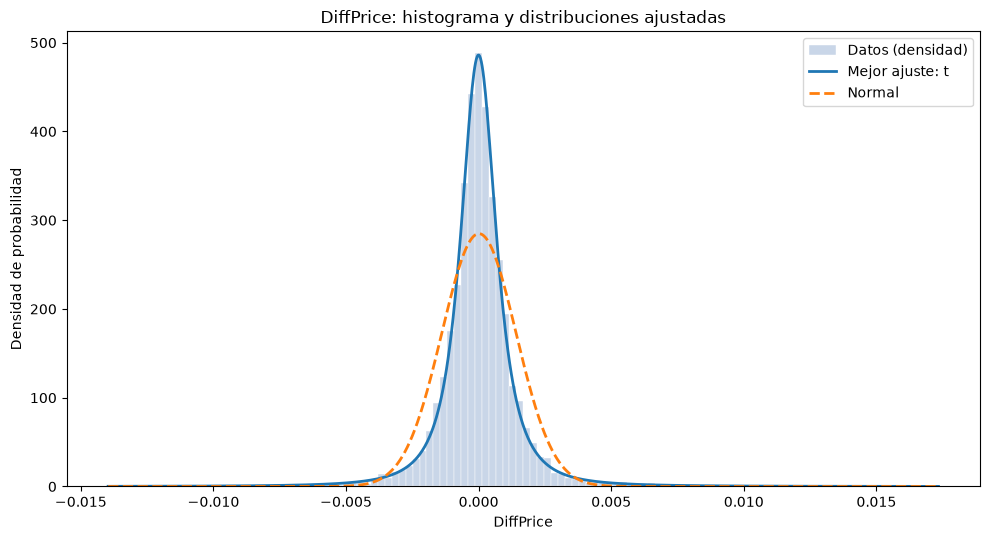

In [105]:
distribucion = getattr(stats, nombre_mejor)
parametros = ajuste.fitted_param[nombre_mejor]

x = np.linspace(diff_precio.min(), diff_precio.max(), 1000)
pdf_mejor = distribucion.pdf(x, *parametros)
pdf_normal = stats.norm.pdf(x, *stats.norm.fit(datos))

plt.figure(figsize=(10, 5.5))
plt.hist(diff_precio, bins=120, density=True, color="#C9D6E8",
         edgecolor="white", linewidth=0.3, label="Datos (densidad)")
plt.plot(x, pdf_mejor, linewidth=2,
         label=f"Mejor ajuste: {nombre_mejor}")
plt.plot(x, pdf_normal, linewidth=2, linestyle="--",
         label="Normal")
plt.title("DiffPrice: histograma y distribuciones ajustadas")
plt.xlabel("DiffPrice")
plt.ylabel("Densidad de probabilidad")
plt.legend()
plt.tight_layout()
plt.show()

In [106]:
#Ahora nos quedamos con los datos del 2023
precio_2023 = precio.loc["2023"].copy()

print("Registros en 2023:", len(precio_2023))
print("Desde:", precio_2023.index.min(), " hasta:", precio_2023.index.max())
precio_2023.head()

Registros en 2023: 2278
Desde: 2023-01-02 00:00:00  hasta: 2023-05-12 23:00:00


,Close,DiffPrice
Time,,
2023-01-02 00:00:00,1.06796,-0.00200
2023-01-02 01:00:00,1.06965,0.00169
2023-01-02 02:00:00,1.07058,0.00093
2023-01-02 03:00:00,1.06896,-0.00162
2023-01-02 04:00:00,1.06880,-0.00016


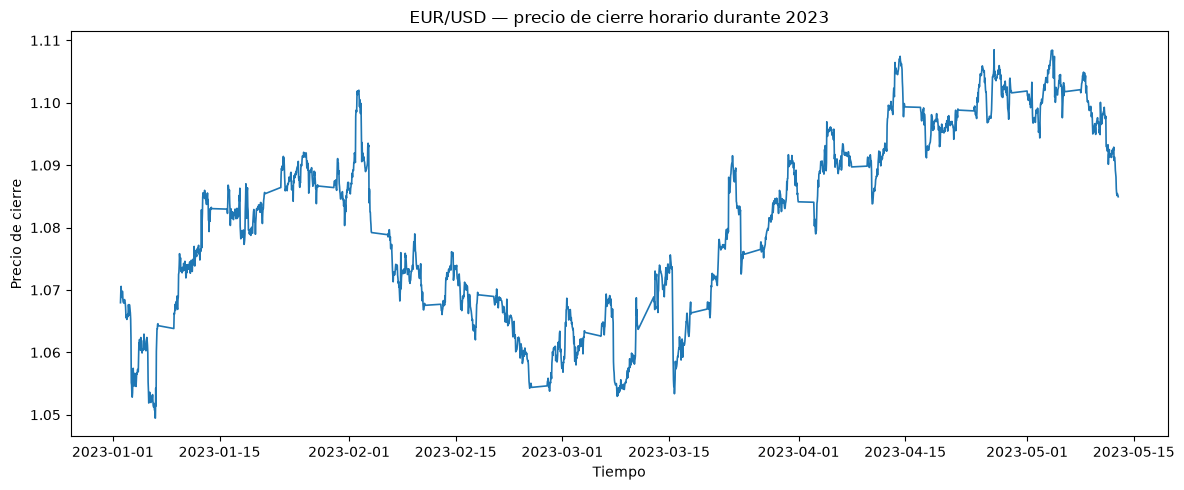

In [107]:
plt.figure(figsize=(12, 5))
plt.plot(precio_2023.index, precio_2023["Close"], linewidth=1.2)
plt.title("EUR/USD — precio de cierre horario durante 2023")
plt.xlabel("Tiempo")
plt.ylabel("Precio de cierre")
plt.tight_layout()
plt.show()

##sacamos los datos de la periodicidad deseada

In [28]:
promedio_15d = precio_2023.groupby(pd.Grouper(freq="15D")).mean()
promedio_15d

,Close,DiffPrice
Time,,
2023-01-02,1.069361,0.000047
2023-01-17,1.085565,0.000015
2023-02-01,1.077679,-0.000066
2023-02-16,1.063150,-0.000034
2023-03-03,1.063186,0.000026
2023-03-18,1.080936,0.000074
2023-04-02,1.093090,0.000063
2023-04-17,1.099084,-0.000006
2023-05-02,1.098889,-0.000059


In [29]:
promedio_semanal = precio_2023.groupby(pd.Grouper(freq="W")).mean()
promedio_semanal

,Close,DiffPrice
Time,,
2023-01-08,1.059972,-0.000047
2023-01-15,1.076002,0.000156
2023-01-22,1.082041,0.000020
2023-01-29,1.088414,0.000010
2023-02-05,1.089281,-0.000062
2023-02-12,1.073363,-0.000097
2023-02-19,1.069648,0.000014
2023-02-26,1.063374,-0.000124
2023-03-05,1.060854,0.000073


In [30]:
promedio_mensual = precio_2023.groupby(pd.Grouper(freq="MS")).mean()
promedio_mensual

,Close,DiffPrice
Time,,
2023-01-01,1.077463,0.000031
2023-02-01,1.071167,-0.000060
2023-03-01,1.070874,0.000049
2023-04-01,1.096051,0.000036
2023-05-01,1.098980,-0.000069


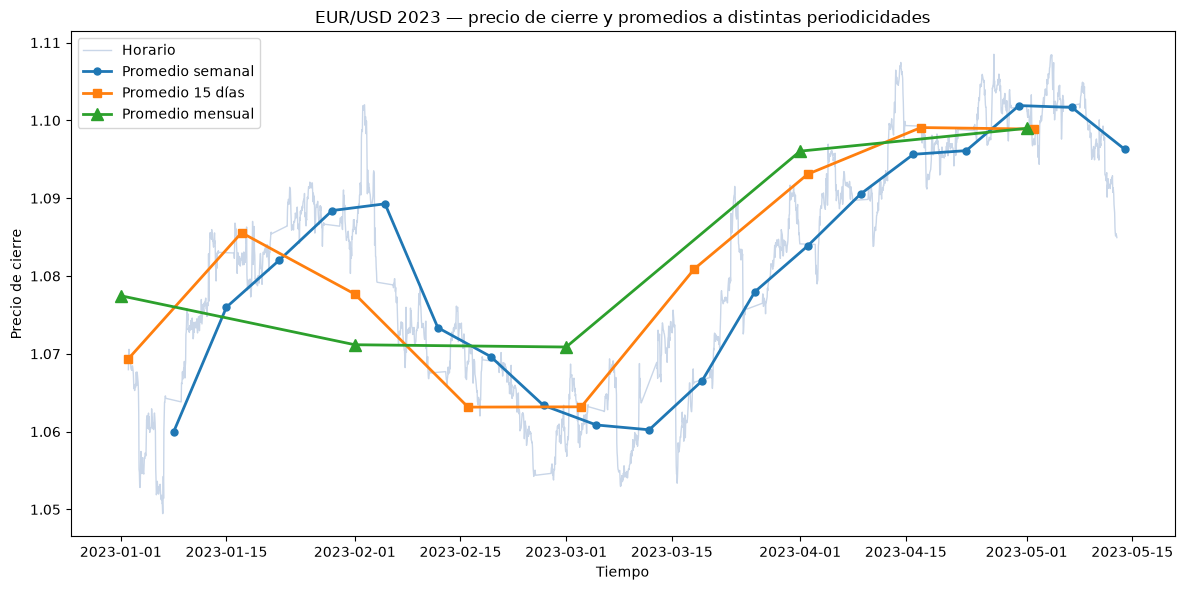

In [31]:
# Comparación gráfica de las tres agregaciones sobre la serie horaria
plt.figure(figsize=(12, 6))
plt.plot(precio_2023.index, precio_2023["Close"], color="#C9D6E8",
         linewidth=1, label="Horario")
plt.plot(promedio_semanal.index, promedio_semanal["Close"],
         linewidth=2, marker="o", markersize=5, label="Promedio semanal")
plt.plot(promedio_15d.index, promedio_15d["Close"],
         linewidth=2, marker="s", markersize=6, label="Promedio 15 días")
plt.plot(promedio_mensual.index, promedio_mensual["Close"],
         linewidth=2, marker="^", markersize=8, label="Promedio mensual")
plt.title("EUR/USD 2023 — precio de cierre y promedios a distintas periodicidades")
plt.xlabel("Tiempo")
plt.ylabel("Precio de cierre")
plt.legend()
plt.tight_layout()
plt.show()

La segmentacion semanal recupera mejor el comportamiento de la serie de tiempo

In [109]:
grupos_mensuales = precio_2023.groupby(pd.Grouper(freq="MS"))

# Primero inspeccionamos qué contiene cada grupo
for nombre, grupo in grupos_mensuales:
    print(f"{nombre.strftime('%Y-%m')}  tiene {len(grupo)} registros")

2023-01  tiene 528 registros
2023-02  tiene 480 registros
2023-03  tiene 550 registros
2023-04  tiene 480 registros
2023-05  tiene 240 registros


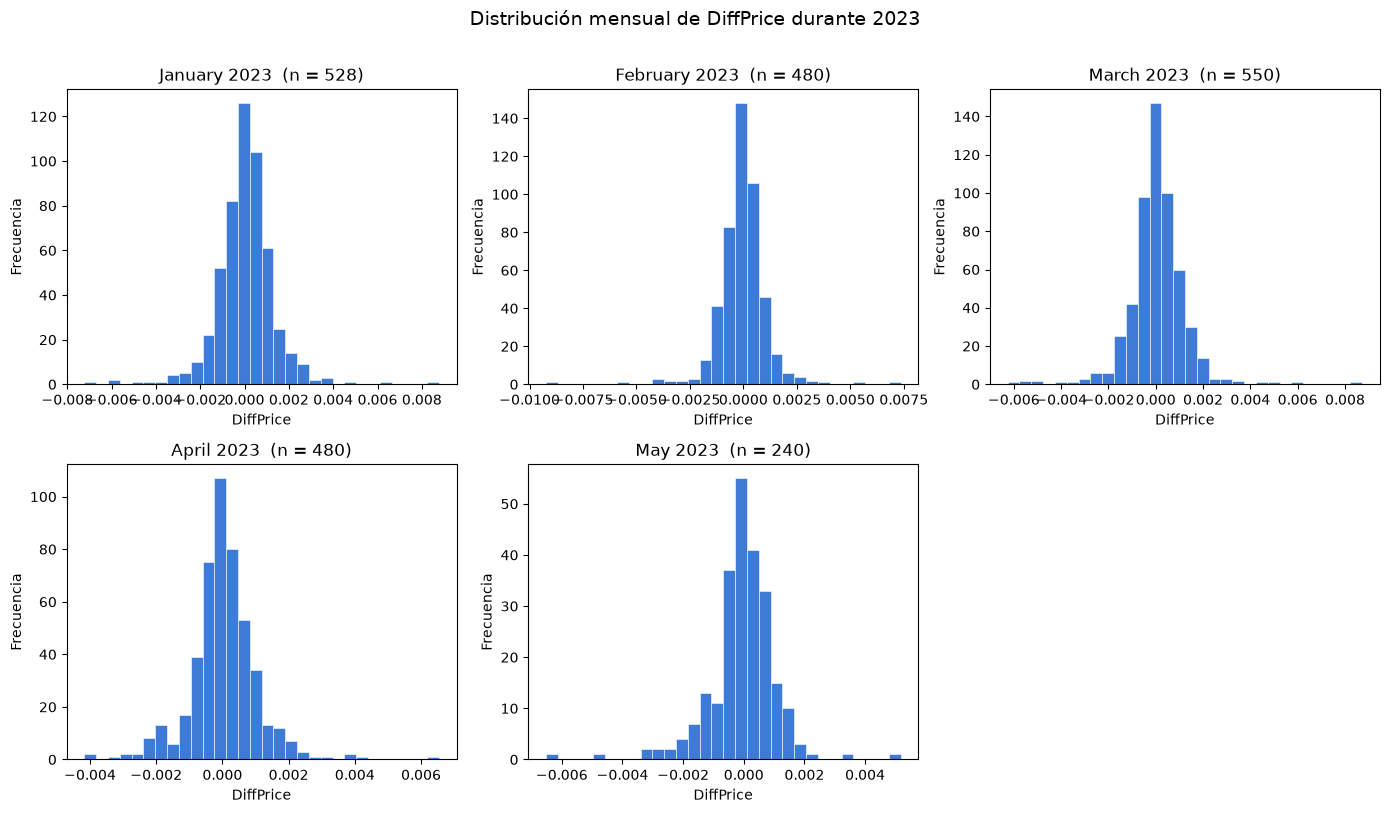

In [110]:
# Guardamos los grupos que no estén vacíos para graficarlos
meses = [(nombre, grupo) for nombre, grupo in grupos_mensuales if len(grupo) > 0]

n_meses = len(meses)
n_columnas = 3
n_filas = int(np.ceil(n_meses / n_columnas))

fig, ejes = plt.subplots(n_filas, n_columnas, figsize=(14, 4 * n_filas))
ejes = np.array(ejes).flatten()

for i, (nombre, grupo) in enumerate(meses):
    datos_mes = grupo["DiffPrice"].dropna()
    ejes[i].hist(datos_mes, bins=30, color="#3D7BD6",
                 edgecolor="white", linewidth=0.4)
    ejes[i].set_title(f"{nombre.strftime('%B %Y')}  (n = {len(datos_mes)})")
    ejes[i].set_xlabel("DiffPrice")
    ejes[i].set_ylabel("Frecuencia")

# Apagamos los ejes sobrantes de la grilla
for j in range(n_meses, len(ejes)):
    ejes[j].axis("off")

fig.suptitle("Distribución mensual de DiffPrice durante 2023", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

#Analisis de datos con Pandas

In [123]:
URL_WDBC = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "breast-cancer-wisconsin/wdbc.data")

rasgos = ["radius", "texture", "perimeter", "area", "smoothness",
          "compactness", "concavity", "concave_points", "symmetry",
          "fractal_dimension"]

# Orden real del archivo: los 10 rasgos con sufijo 1, luego con 2, luego con 3
nombres_columnas = ["id", "diagnosis"] + [f"{r}{i}" for i in (1, 2, 3) for r in rasgos]
cancer = pd.read_csv(URL_WDBC, header=None, names=nombres_columnas)

In [124]:
#Renombramos en formato PascalCase
cancer = cancer.rename(columns=a_pascal_case)

##Utilizamos los metodos para obtener informacion de Dataframe

 `head()`, `tail()`, `describe()` e `info()`

In [125]:
cancer.head()

,Id,Diagnosis,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [126]:
cancer.tail()

,Id,Diagnosis,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [127]:
cancer.describe()

,Id,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [128]:
cancer.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 569 non-null    int64  
 1   Diagnosis          569 non-null    str    
 2   Radius1            569 non-null    float64
 3   Texture1           569 non-null    float64
 4   Perimeter1         569 non-null    float64
 5   Area1              569 non-null    float64
 6   Smoothness1        569 non-null    float64
 7   Compactness1       569 non-null    float64
 8   Concavity1         569 non-null    float64
 9   ConcavePoints1     569 non-null    float64
 10  Symmetry1          569 non-null    float64
 11  FractalDimension1  569 non-null    float64
 12  Radius2            569 non-null    float64
 13  Texture2           569 non-null    float64
 14  Perimeter2         569 non-null    float64
 15  Area2              569 non-null    float64
 16  Smoothness2        569 non-null    fl

In [129]:
#Contamos los nulos
nulos = cancer.isnull().sum()
print("Valores nulos por columna :")
print(nulos[nulos > 0] if (nulos > 0).any() else "No hay nulos")
print()
print("Nulos totales:", cancer.isnull().sum().sum())

Valores nulos por columna :
No hay nulos

Nulos totales: 0


Este dataset está no tiene nulos, pero si aparecieran valores faltantes la estrategia
dependería del tipo de variable y de la cantidad de datos perdidos:

1. Para pocos faltantes (< 5 %) en variables numéricas: imputar con la mediana
   de la columna, que es robusta frente a los outliers que sí tiene este dataset, en esos casos la mediana es mas adecuada que la media.

2. Si hay Muchos faltantes en una columna (> 40 %):eliminar la columna, pues la
   imputación introduciría más ruido que información.


In [130]:
#Identificamos los valores unicos
print("Valores únicos:", cancer["Diagnosis"].unique())
print()
print("Conteo por etiqueta:")
print(cancer["Diagnosis"].value_counts())
print()
print("Proporción:")
print((cancer["Diagnosis"].value_counts(normalize=True) * 100).round(2))

Valores únicos: <ArrowStringArray>
['M', 'B']
Length: 2, dtype: str

Conteo por etiqueta:
Diagnosis
B    357
M    212
Name: count, dtype: int64

Proporción:
Diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


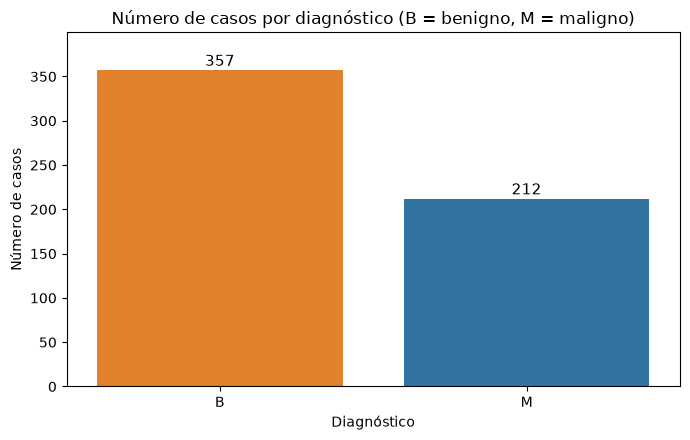

In [133]:
plt.figure(figsize=(7, 4.5))
sns.countplot(data=cancer, x="Diagnosis", hue="Diagnosis",
              order=["B", "M"],
              legend=False)

# Etiquetas directas sobre cada barra: la identidad no depende solo del color
for i, etiqueta in enumerate(["B", "M"]):
    conteo = (cancer["Diagnosis"] == etiqueta).sum()
    plt.text(i, conteo + 5, str(conteo), ha="center", fontsize=11)

plt.title("Número de casos por diagnóstico (B = benigno, M = maligno)")
plt.xlabel("Diagnóstico")
plt.ylabel("Número de casos")
plt.ylim(0, cancer["Diagnosis"].value_counts().max() * 1.12)
plt.tight_layout()
plt.show()

El dataset está moderadamente desbalanceado con un 63 %  de benignos y un 37 % de malignos.

In [134]:
#Le asignamos valores numericos a Beningno (0) y Malingo (1)
cancer["DiagnosisNumeric"] = cancer["Diagnosis"].map({"B": 0, "M": 1})

 Normalizamos cada columna respecto a su media y desviación estándar utilizando la fórmula:  
   `(x - mean(x)) / std(x)`

In [135]:
#Normalizamos cada columna respecto a su media y su desviacion estandar

columnas_caracteristicas = [c for c in cancer.columns
                            if c not in ("Diagnosis", "DiagnosisNumeric")]

caracteristicas = cancer[columnas_caracteristicas]
cancer_norm = (caracteristicas - caracteristicas.mean()) / caracteristicas.std()

# Conservamos las etiquetas junto a los datos normalizados
cancer_norm["Diagnosis"] = cancer["Diagnosis"]

cancer_norm.head()

,Id,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
0,-0.236197,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,2.215566,...,-1.358098,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312,M
1,-0.236196,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,0.001391,...,-0.368879,1.533776,1.888827,-0.375282,-0.430066,-0.146620,1.086129,-0.243675,0.280943,M
2,0.431362,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,0.938859,...,-0.023953,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214,M
3,0.431741,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,2.864862,...,0.133866,-0.249720,-0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672,M
4,0.431821,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,-0.009552,...,-1.465481,1.337363,1.219651,0.220362,-0.313119,0.612640,0.728618,-0.867590,-0.396751,M


In [49]:
# la media es cero y la desviacion estandar debe ser uno
comprobacion = pd.DataFrame({
    "Media": cancer_norm[columnas_caracteristicas].mean(),
    "DesvEst": cancer_norm[columnas_caracteristicas].std(),
})
comprobacion.round(6).head(10)

,Media,DesvEst
Id,0.0,1.0
Radius1,-0.0,1.0
Texture1,0.0,1.0
Perimeter1,-0.0,1.0
Area1,-0.0,1.0
Smoothness1,-0.0,1.0
Compactness1,0.0,1.0
Concavity1,0.0,1.0
ConcavePoints1,-0.0,1.0
Symmetry1,0.0,1.0


In [50]:
# La regex toma solo las letras iniciales, descartando el dígito final
for ejemplo in ["Radius1", "Radius2", "ConcavePoints3", "FractalDimension3"]:
    print(f"{ejemplo:20s} -> {re.match(r'^[a-zA-Z_]+', ejemplo).group(0)}")

Radius1              -> Radius
Radius2              -> Radius
ConcavePoints3       -> ConcavePoints
FractalDimension3    -> FractalDimension


In [53]:
#  Agrupamos  caracteristicas familiares en familias
familias = {}
for columna in columnas_caracteristicas:
    base = re.match(r"^[a-zA-Z_]+", columna).group(0)
    familias.setdefault(base, []).append(columna)

for base, columnas in familias.items():
    print(f"{base:20s} -> {columnas}")

Id                   -> ['Id']
Radius               -> ['Radius1', 'Radius2', 'Radius3']
Texture              -> ['Texture1', 'Texture2', 'Texture3']
Perimeter            -> ['Perimeter1', 'Perimeter2', 'Perimeter3']
Area                 -> ['Area1', 'Area2', 'Area3']
Smoothness           -> ['Smoothness1', 'Smoothness2', 'Smoothness3']
Compactness          -> ['Compactness1', 'Compactness2', 'Compactness3']
Concavity            -> ['Concavity1', 'Concavity2', 'Concavity3']
ConcavePoints        -> ['ConcavePoints1', 'ConcavePoints2', 'ConcavePoints3']
Symmetry             -> ['Symmetry1', 'Symmetry2', 'Symmetry3']
FractalDimension     -> ['FractalDimension1', 'FractalDimension2', 'FractalDimension3']


In [54]:
# Promedio de cada familia; el nombre resultante es Base + 'Mean'
cancer_promedios = pd.DataFrame(index=cancer.index)

for base, columnas in familias.items():
    cancer_promedios[base + "Mean"] = cancer[columnas].mean(axis=1)

cancer_promedios["Diagnosis"] = cancer["Diagnosis"]

print("Columnas resultantes:", list(cancer_promedios.columns))
cancer_promedios.head()

Columnas resultantes: ['IdMean', 'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean', 'Diagnosis']


,IdMean,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean,Diagnosis
0,842302.0,14.821667,9.538433,105.329667,1057.800000,0.095666,0.330747,0.355243,0.142790,0.244010,0.067934,M
1,842517.0,15.367833,13.971300,98.366000,1118.693333,0.071255,0.092773,0.115700,0.089857,0.156697,0.049741,M
2,84300903.0,14.668533,15.855633,95.695000,1002.010000,0.086717,0.208153,0.228707,0.130493,0.196900,0.050714,M
3,84348301.0,8.941867,16.012000,59.965000,327.010000,0.120470,0.408260,0.328303,0.127123,0.327710,0.093216,M
4,84358402.0,14.529067,10.597100,97.579333,988.813333,0.083063,0.120803,0.218293,0.095217,0.144953,0.046908,M


In [56]:
# Promedio de cada familia separado por diagnóstico
cancer_promedios.groupby("Diagnosis").mean().round(3)

,IdMean,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean
Diagnosis,,,,,,,,,,,
B,2.654382e+07,8.603,14.217,55.694,347.608,0.075,0.095,0.079,0.037,0.155,0.049
M,3.681805e+07,13.069,17.378,87.020,824.445,0.085,0.184,0.218,0.095,0.179,0.053


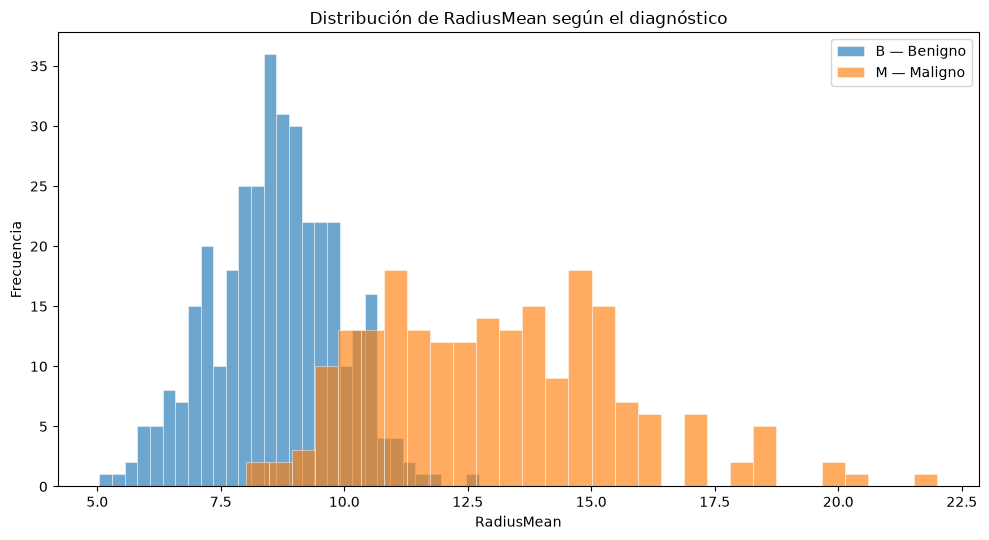

RadiusMean promedio  |  Benigno: 8.603   Maligno: 13.069


In [58]:
#Veamos el radio medio en el vaso Benigno y Maligno
radio_benigno = cancer_promedios.loc[cancer_promedios["Diagnosis"] == "B", "RadiusMean"]
radio_maligno = cancer_promedios.loc[cancer_promedios["Diagnosis"] == "M", "RadiusMean"]

plt.figure(figsize=(10, 5.5))
plt.hist(radio_benigno, bins=30, alpha=0.65,
         edgecolor="white", linewidth=0.5, label="B — Benigno")
plt.hist(radio_maligno, bins=30, alpha=0.65,
         edgecolor="white", linewidth=0.5, label="M — Maligno")
plt.title("Distribución de RadiusMean según el diagnóstico")
plt.xlabel("RadiusMean")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

print(f"RadiusMean promedio  |  Benigno: {radio_benigno.mean():.3f}"
      f"   Maligno: {radio_maligno.mean():.3f}")

Los tumores malignos tienen un radio claramente mayor, las distribuciones se
solapan poco, así que el radio medio es una variable con buen poder de diferenciacion

In [136]:
# Normalizamos también la tabla de promedios por familia
columnas_promedio = [c for c in cancer_promedios.columns if c != "Diagnosis"]
promedios_norm = ((cancer_promedios[columnas_promedio]
                   - cancer_promedios[columnas_promedio].mean())
                  / cancer_promedios[columnas_promedio].std())
promedios_norm["Diagnosis"] = cancer_promedios["Diagnosis"]

# Utulizamos las caracteristicas del enunciado
columnas_violin = ["RadiusMean", "TextureMean", "PerimeterMean", "AreaMean",
                   "SmoothnessMean", "CompactnessMean", "ConcavityMean",
                   "ConcavePointsMean", "Symmetry3", "FractalDimension3"]

# Las ocho primeras salen de los promedios; las dos últimas del dataset original
tabla_violin = promedios_norm[columnas_violin[:8] + ["Diagnosis"]].copy()
tabla_violin["Symmetry3"] = cancer_norm["Symmetry3"]
tabla_violin["FractalDimension3"] = cancer_norm["FractalDimension3"]

tabla_violin.head()

,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,Diagnosis,Symmetry3,FractalDimension3
0,1.608815,-1.679618,1.932219,1.682034,1.411893,2.791123,2.219879,2.381444,M,2.748204,1.935312
1,1.801743,-0.408214,1.577798,1.874370,-0.606461,-0.485403,-0.151044,0.886974,M,-0.243675,0.280943
2,1.554722,0.132238,1.441855,1.505817,0.671925,1.103202,0.967460,2.034272,M,1.151242,0.201214
3,-0.468167,0.177086,-0.376651,-0.626217,3.462686,3.858363,1.953236,1.939126,M,6.040726,4.930672
4,1.505457,-1.375978,1.537760,1.464135,0.369864,-0.099473,0.864392,1.038304,M,-0.867590,-0.396751


##Grafico tipo violin

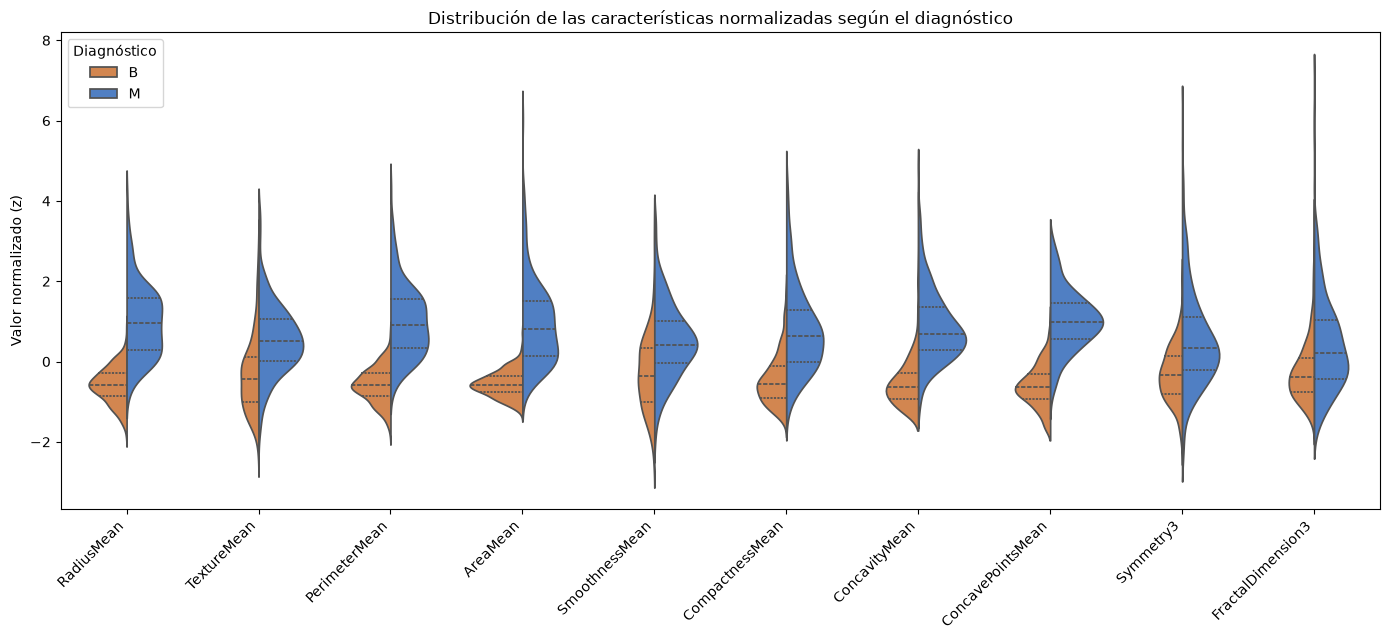

In [63]:

datos_largos = pd.melt(tabla_violin, id_vars="Diagnosis",
                       var_name="Caracteristica", value_name="Valor")

plt.figure(figsize=(14, 6.5))
sns.violinplot(x="Caracteristica", y="Valor", hue="Diagnosis",
               data=datos_largos, split=True, inner="quart",
               hue_order=["B", "M"],
               palette={"B": "#E8833A", "M": "#3D7BD6"})
plt.xticks(rotation=45, ha="right")
plt.title("Distribución de las características normalizadas según el diagnóstico")
plt.xlabel("")
plt.ylabel("Valor normalizado (z)")
plt.legend(title="Diagnóstico")
plt.tight_layout()
plt.show()

En `RadiusMean`, `PerimeterMean`, `AreaMean`,
`ConcavityMean` y `ConcavePointsMean` los dos violines están claramente
desplazados uno respecto del otro, por lo tanto tendremos una buena separación entre clases. En
`SmoothnessMean`, `Symmetry3` y `FractalDimension3` se superponen casi por
completo, por tanto, aportan poca información de diferenciacion por sí solas.

##Outliers


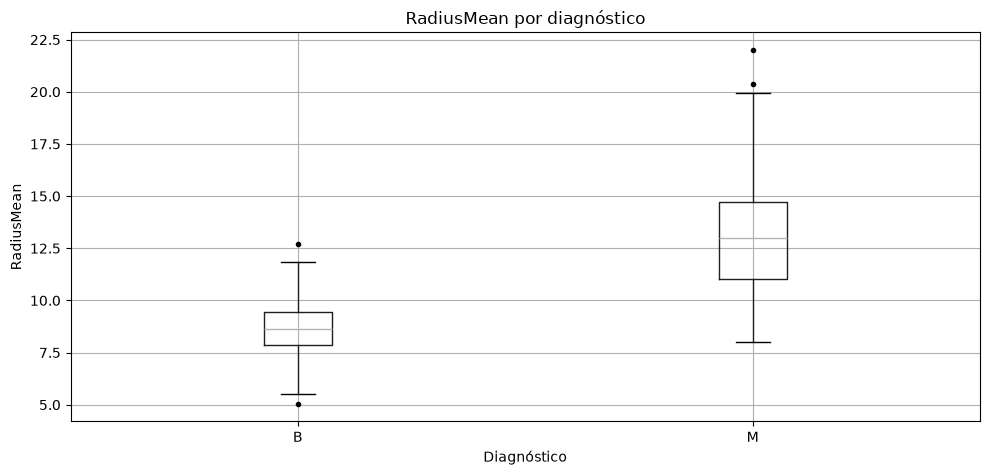

In [64]:
cancer_promedios.boxplot(column="RadiusMean", by="Diagnosis",
                         sym="k.", figsize=(10, 5))
plt.title("RadiusMean por diagnóstico")
plt.suptitle("")          # quita el título automático de pandas
plt.xlabel("Diagnóstico")
plt.ylabel("RadiusMean")
plt.tight_layout()
plt.show()

Los valores fuera del rango [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] se consideran outliers.

In [65]:
Q1 = cancer_promedios["RadiusMean"].quantile(0.25)
Q3 = cancer_promedios["RadiusMean"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1  = {Q1:.4f}")
print(f"Q3  = {Q3:.4f}")
print(f"IQR = {IQR:.4f}")
print(f"Rango aceptado: [{limite_inferior:.4f}, {limite_superior:.4f}]")

Q1  = 8.3545
Q3  = 11.6924
IQR = 3.3379
Rango aceptado: [3.3476, 16.6993]


In [137]:
mascara_outliers = ((cancer_promedios["RadiusMean"] < limite_inferior) |
                    (cancer_promedios["RadiusMean"] > limite_superior))


In [138]:
# Eliminamos los outliers
cancer_sin_outliers = cancer_promedios[~mascara_outliers].copy()

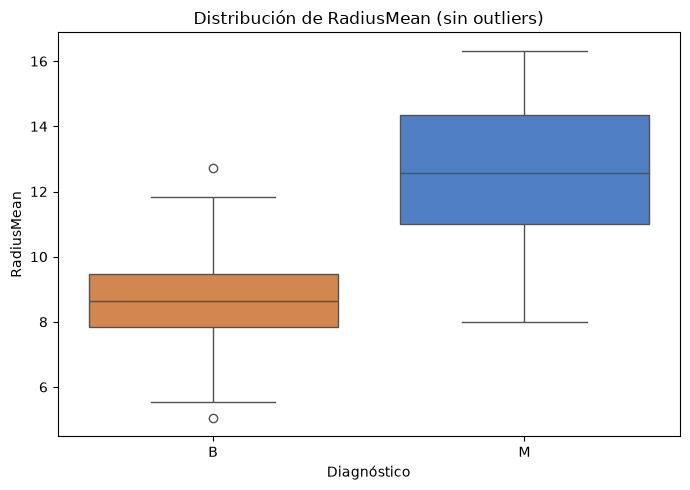

In [139]:
# Gráfico de la distribución de RadiusMean solo para los datos sin outliers
plt.figure(figsize=(7, 5))
sns.boxplot(data=cancer_sin_outliers, x="Diagnosis", y="RadiusMean",
            hue="Diagnosis", order=["B", "M"], legend=False,
            palette={"B": "#E8833A", "M": "#3D7BD6"})
plt.title("Distribución de RadiusMean (sin outliers)")
plt.xlabel("Diagnóstico")
plt.ylabel("RadiusMean")
plt.tight_layout()
plt.show()


In [71]:
# Correlación entre las 10 familias promediadas (matriz legible)
matriz_correlacion = cancer_promedios.drop(columns="Diagnosis").corr()


##Matriz de correlacion

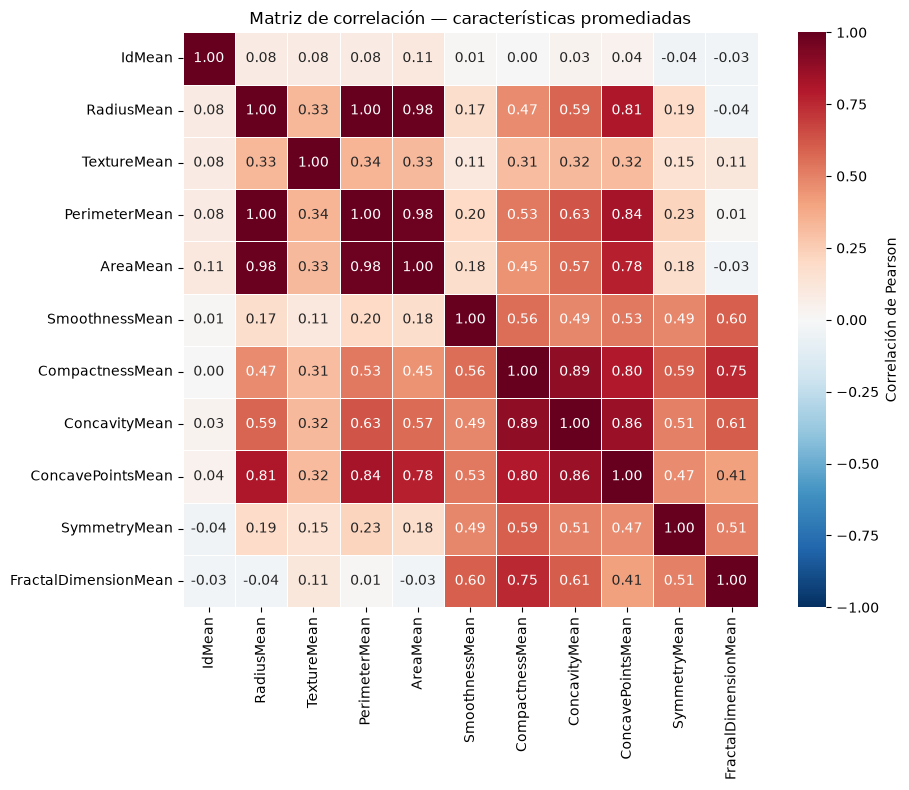

In [72]:
#Primero visualizamos el de las familias promediadas
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"label": "Correlación de Pearson"})
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

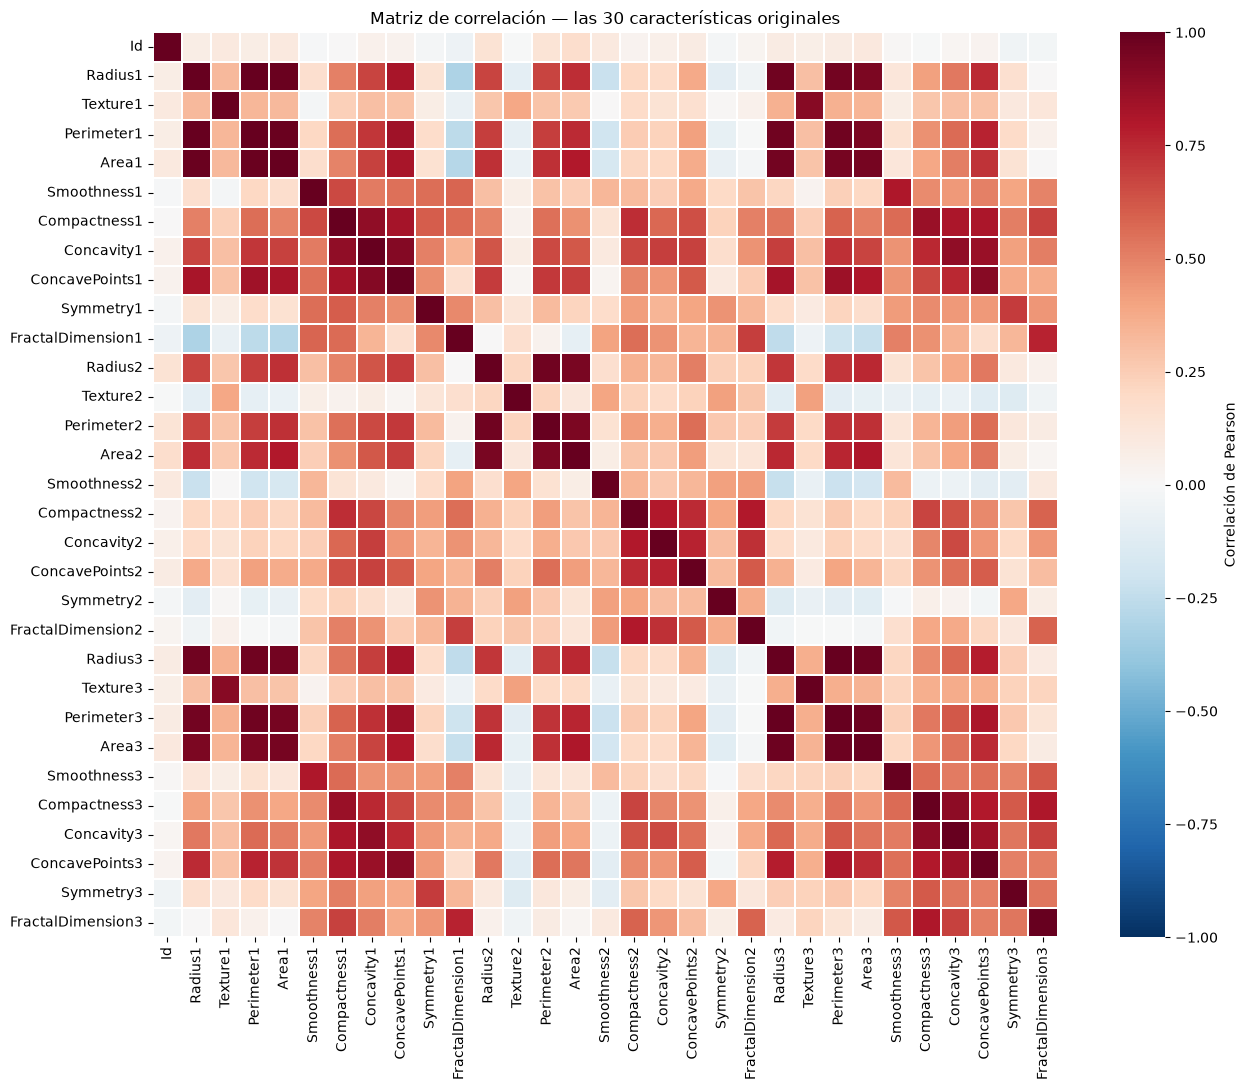

In [73]:
# Matriz completa con las 30 características originales del DataSet
plt.figure(figsize=(14, 11))
sns.heatmap(cancer[columnas_caracteristicas].corr(),
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.2,
            cbar_kws={"label": "Correlación de Pearson"})
plt.title("Matriz de correlación — las 30 características originales")
plt.tight_layout()
plt.show()

Con esto vemos cuales son las caracteristicas mas relacionadas con el diagnostico. Se dejan en la siguinte lista por que en este caso me parece dificil visualizar este heatmap

In [140]:
correlacion_con_diagnostico = (cancer[columnas_caracteristicas + ["DiagnosisNumeric"]]
                               .corr()["DiagnosisNumeric"]
                               .drop("DiagnosisNumeric")
                               .sort_values(ascending=False))

print("Las 10 características más correlacionadas con un diagnóstico maligno:")
print(correlacion_con_diagnostico.head(10).round(3))

Las 10 características más correlacionadas con un diagnóstico maligno:
ConcavePoints3    0.794
Perimeter3        0.783
ConcavePoints1    0.777
Radius3           0.776
Perimeter1        0.743
Area3             0.734
Radius1           0.730
Area1             0.709
Concavity1        0.696
Concavity3        0.660
Name: DiagnosisNumeric, dtype: float64


##Grafico adicional
Podemos hacer un grafico de sispersion entre las variables corelacionadas que identificamos anteriormente y  ver si es posible separarlas, similar a lo que haciamos en el dataset de pinguinos

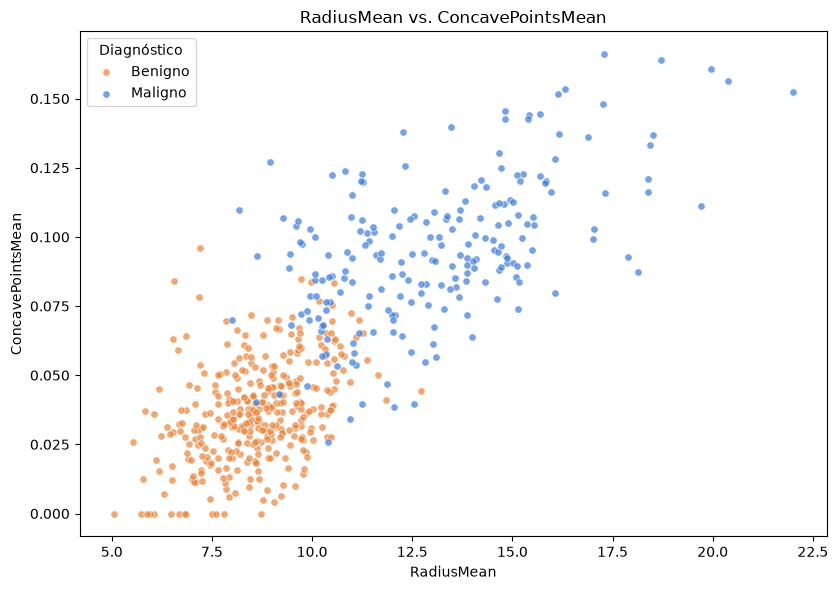

In [144]:
plt.figure(figsize=(8.5, 6))
for etiqueta, color, nombre in [("B", "#E8833A", "Benigno"),
                                ("M", "#3D7BD6" , "Maligno")]:
    subconjunto = cancer_promedios[cancer_promedios["Diagnosis"] == etiqueta]
    plt.scatter(subconjunto["RadiusMean"], subconjunto["ConcavePointsMean"],
                s=28, alpha=0.7, color=color, edgecolor="white",
                linewidth=0.6, label=nombre)

plt.title("RadiusMean vs. ConcavePointsMean")
plt.xlabel("RadiusMean")
plt.ylabel("ConcavePointsMean")
plt.legend(title="Diagnóstico")
plt.tight_layout()
plt.show()